In [7]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy.ma as ma

# python笔记

## python 面向对象

python整数，浮点数，字符串，布尔值均为不可变对象，但是可以有多个指针指向这个对象；
没有指针指向的对象会被自动清除，释放内存，这里应该是用一个计数器实现的

In [ ]:
a = 1 #本质上是基于int 类建立一个实例 1, 然后把地址传递给a

In [ ]:
a = 'xyz'
b = 'xyz' # a is b
a = 1
b = 1 # a is b
a = 300
b = 300 # a is b  -> False
# 这些东西取决与解释器的优化问题，不同实现可能不同

list，tuple，set，dict本质上是容器对象，容器内的每一个位置存储一个指针，

In [ ]:
a = [1,2] #建立了一个list实例，

python中的变量实际上可以认为是名称，名称不是对象的属性，

变量的本质是一个指针，对变量赋值实际上是改变变量的指针，所以可以实现动态语言；
这里所谓的指针是没有类型的，和c语言不同

In [ ]:
a = "abc"
b = a
b.replace("c", "x") # 会返回一个新的"abx"，但是b还是"abc"，且b is a。

## 深浅拷贝

In [7]:
import copy
a = [[1,2],3]
b = a # 直接赋值
b = copy.copy(a) # 浅拷贝
b = copy.deepcopy(a) # 深拷贝

直接赋值就是把指针赋值给b，a和b指向同一个list对象[[1,2],3]；
浅拷贝是复制一个a指向的list对象，然后赋值给b，此时a和b指向不同的list对象，但两个list对象的子对象是同一个[1,2]；
深拷贝是复制list对象及其子对象，然后赋值给b，相当于a和b没有任何共用的对象。

## python 函数

函数定义为：

In [9]:
def fuc(a,*args,b='b',**kw): #b是默认参数
    """请使用文档字符串。
    
    """
    pass

函数的默认参数在函数定义的时候就计算好了，默认参数汇总成一个tuple作为函数对象的 _default_ 属性，
所以默认参数如果是不可变对象的话，无论怎么调用函数，默认参数都不会变，但如果默认参数是可变对象的话，
属性所指的位置不会变，但该位置的对象可以变。

In [ ]:
fuc(1,b=2) #b是关键字参数

调用函数的时候必须先写位置参数，后写关键字参数，多余的位置参数会保存在args这个tuple中，多余的关键字参数会保存在kw这个dict中。

如果函数定义时没有*args，fuc(1,2)可以把2传给b，但我认为这不是一种好的书写习惯，默认参数如果要改一定要用关键字参数

函数用 return 返回值，函数通过返回多个值时，实际上返回的是 tuple ，没有 return 时，最后返回 None。

写python函数时要考虑错误和异常处理，比如对函数传入参数的数据类型的检查

## 基本数据结构

### 切片

In [ ]:
L[:3] #[L[0],l[1],L[2]]
L[1:3]
L[-2:] #从倒数第二个开始
L[-2:-1]
L[:10:2] #每两个
L[::5] #每五个
# 也适用于tuple

### 迭代

In [ ]:
for val in list:
for i,val in enumerate(list):
for key in dict:
for val in dict.values():
for key,val in dict.items():
for char in 'abc':
# 能用for迭代的对象都是 Iterable

### List comprehension

In [ ]:
[x if x % 2 == 0 else -x for x in range(1, 11) if x > 1]
# 前面的if-else是表达式，后面的if是过滤条件

## 模块

In [ ]:
模块就是一个代码文件，模块里面定义函数和属性，用于别的程序import

一个模块被另一个程序第一次引入时，其主程序将运行，即使是通过from ... import ...引入部分，主程序也是运行的。

In [ ]:
if __name__ == "__main__":

In [ ]:
模块组成的文件架即为包，一个包中必须有一个 __init__.py 文件，包可以嵌套

## numpy

### numpy的ndarray数据的组织逻辑

ndarray逻辑上认为是一个数组，多位数组的每一个元素是一个维数减一的数组

In [3]:
a = np.array([[[[1,2],[3,4],[5,6]],[[7,8],[9,10],[11,12]]],[[[1,2],[3,4],[5,6]],[[7,8],[9,10],[11,12]]]])

In [4]:
a

array([[[[ 1,  2],
         [ 3,  4],
         [ 5,  6]],

        [[ 7,  8],
         [ 9, 10],
         [11, 12]]],


       [[[ 1,  2],
         [ 3,  4],
         [ 5,  6]],

        [[ 7,  8],
         [ 9, 10],
         [11, 12]]]])

In [6]:
a[0]

array([[[ 1,  2],
        [ 3,  4],
        [ 5,  6]],

       [[ 7,  8],
        [ 9, 10],
        [11, 12]]])

可以看出,a是一个四维的张量，a[0]是最外层数组的第一个元素，是一个三维的张量。

### ndarray的每一个元素也是有数据类型的

ndarray的每一个元素也是有数据类型的,a.dtype()

In [ ]:
a = a.astype(np.float64)

有些时候，ndarray的每个元素会莫名其妙地被定义为object，有时候后面用到时会出问题
比如，object ndarray在pcolormesh的时候会出问题，
可以手动地改过来。

### python的ndarray和数学上的习惯的区别

python有一个很大的陷阱，就是它的矩阵排列的方式和我们想当然的想法是不一样的，
python的ndarray的[0,0]是从左上角开始数的，而数学中矩阵的零点在左下角。

下面表达式中，z[0,0]=3

In [16]:
x = np.array([0,1])
y = np.array([3,4,5])
xx,yy = np.meshgrid(x,y)
z = xx+yy
z

array([[3, 4],
       [4, 5],
       [5, 6]])

其次，`z[1,0]`中`1`为最外围维度的坐标，`0`为最内维的坐标，所以
`z[1,0]=x[0]+y[1]`，
容易想当然地认为`z[1,0]=x[1]+y[0]`

In [17]:
z[1,0]

4

`z[1]`是`z`的1号元素，即为`z[1,:]`，也即限定`y=1`，`x`自由的向量。

In [18]:
z[1]

array([4, 5])

In [19]:
z[1,:]

array([4, 5])

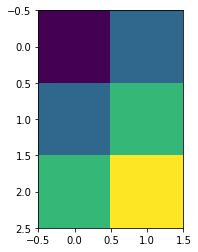

In [28]:
plt.imshow(z)

### 矢量运算函数的组合

如果有两个矢量函数，想要定义一个新矢量函数，让它在某些位置为前一个函数，某些位置为后一个函数，目前我没找到什么好的办法

### numpy 一定要注意拷贝是浅拷贝还是深拷贝

## sympy

sympy中变量指向一个symbol，一个变量是另外一个变量时，值得symbol之间得关系

In [ ]:
x = sp.Symbol('x')
y = sp.Symbol('y')
A = sp.Symbol('A')
B = sp.Symbol('B')
C = sp.Symbol('C')
D = sp.Symbol('D')
mu = sp.Symbol('mu')
U = sp.Symbol('U')
theta = sp.Symbol('theta')

在使用sympy时,数学函数要用sympy提供的，比如`sp.tan()`。

### atan2(y,x)真是一个好函数

In [ ]:
使用sympy

In [ ]:
u = -B-D*sp.atan(y/x)+(C*x+D*y)*(-x/(x**2+y**2))
v = A+C*sp.atan(y/x)+(C*x+D*y)*(-x/(x**2+y**2))
P = -2*mu*(C*x+D*y)/(x**2+y**2)

`sp.simplify()`用来化简表达式，`sp.diff(v,x)`用来求导

In [ ]:
tau_xx = sp.simplify(2*mu*sp.diff(u,x))
tau_yy = sp.simplify(2*mu*sp.diff(v,y))
tau_xy = sp.simplify(mu*(sp.diff(u,y)+sp.diff(v,x)))
tau_yx = tau_xy

用`sp.solve()`来求解代数方程，解出来的解是一个list里嵌套的一个touple

In [ ]:
solve1 = sp.solve([B+C,A,y-x*sp.tan(theta),u-U*sp.cos(theta),v-U*sp.sin(theta)],[x,y,A,B,C,D,U])
A1 = solve1[0][2]
B1 = solve1[0][3]
C1 = solve1[0][4]
D1 = solve1[0][5]

用`u.subs({})`来替代表达式中的symbol

In [ ]:
u1 = u.subs({A:A1,B:B1,C:C1,D:D1,theta:np.pi/6,mu:10**20,U:5})
v1 = v.subs({A:A1,B:B1,C:C1,D:D1,theta:np.pi/6,mu:10**20,U:5})
P1 = P.subs({A:A1,B:B1,C:C1,D:D1,theta:np.pi/6,mu:10**20,U:5})
tau_xx1 = tau_xx.subs({A:A1,B:B1,C:C1,D:D1,theta:np.pi/6,mu:10**20,U:5})
tau_yy1 = tau_yy.subs({A:A1,B:B1,C:C1,D:D1,theta:np.pi/6,mu:10**20,U:5})
tau_xy1 = tau_xy.subs({A:A1,B:B1,C:C1,D:D1,theta:np.pi/6,mu:10**20,U:5})
tau_yx1 = tau_xy1

用`sp.lambdify([x,y],u,"numpy")`来将表达式转化成numpy函数

In [ ]:
npf_u1 = sp.lambdify([x,y],u1,"numpy")# numpy function
npf_v1 = sp.lambdify([x,y],v1,"numpy")
npf_P1 = sp.lambdify([x,y],P1,"numpy")
npf_tau_xx1 = sp.lambdify([x,y],tau_xx1,'numpy')
npf_tau_yy1 = sp.lambdify([x,y],tau_yy1,'numpy')
npf_tau_xy1 = sp.lambdify([x,y],tau_xy1,'numpy')
npf_tau_yx1 = npf_tau_xy1

转化后的函数可以直接用于矢量运算（指对矢量每一个元素运算）

In [ ]:
xgrid = np.linspace(-100,400,500)
ygrid = np.linspace(0,300,300)
xxgrid, yygrid = np.meshgrid(xgrid,ygrid)
nd_u1 = npf_u1(xxgrid,yygrid)

## matplotlib

### seaborn是个画统计数据图的好东西，可以抽空学一下